## Predicting Survival on the Titanic

### History
Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### Assignment:

Build a Machine Learning Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and complete the missing bits of code, to achieve each one of the pipeline steps.

In [1]:
import re

# to handle datasets
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import StandardScaler

# to build the models
from sklearn.linear_model import LogisticRegression

# to evaluate the models
from sklearn.metrics import accuracy_score, roc_auc_score

# to persist the model and the scaler
import joblib

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

## Prepare the data set

In [2]:
# load the data - it is available open source and online

data = pd.read_csv('https://www.openml.org/data/get_csv/16826755/phpMYEkMl')

# display data
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [3]:
# replace interrogation marks by NaN values

data = data.replace('?', np.nan)

In [4]:
# retain only the first cabin if more than
# 1 are available per passenger

def get_first_cabin(row):
    try:
        return row.split()[0]
    except:
        return np.nan
    
data['cabin'] = data['cabin'].apply(get_first_cabin)

In [5]:
# extracts the title (Mr, Ms, etc) from the name variable

def get_title(passenger):
    line = passenger
    if re.search('Mrs', line):
        return 'Mrs'
    elif re.search('Mr', line):
        return 'Mr'
    elif re.search('Miss', line):
        return 'Miss'
    elif re.search('Master', line):
        return 'Master'
    else:
        return 'Other'
    
data['title'] = data['name'].apply(get_title)

In [6]:
# cast numerical variables as floats

data['fare'] = data['fare'].astype('float')
data['age'] = data['age'].astype('float')

In [7]:
# drop unnecessary variables

data.drop(labels=['name','ticket', 'boat', 'body','home.dest'], axis=1, inplace=True)

# display data
data.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,title
0,1,1,female,29.0000,0,0,211.3375,B5,S,Miss
1,1,1,male,0.9167,1,2,151.5500,C22,S,Master
2,1,0,female,2.0000,1,2,151.5500,C22,S,Miss
3,1,0,male,30.0000,1,2,151.5500,C22,S,Mr
4,1,0,female,25.0000,1,2,151.5500,C22,S,Mrs


In [8]:
# save the data set

data.to_csv('titanic.csv', index=False)

## Data Exploration

### Find numerical and categorical variables

In [8]:
target = 'survived'

In [9]:
vars_num = [var for var in data.columns if data[var].dtype != 'O' and var != target]
vars_cat = [var for var in data.columns if data[var].dtype == 'O' and var != target]

print('Number of numerical variables: {}'.format(len(vars_num)))
print('Number of categorical variables: {}'.format(len(vars_cat)))

Number of numerical variables: 5
Number of categorical variables: 4


### Find missing values in variables

In [14]:
# first in numerical variables
num_na = [var for var in vars_num if any(data[var].isnull())]

In [15]:
# now in categorical variables
cat_na = [var for var in vars_cat if any(data[var].isnull())]

### Determine cardinality of categorical variables

In [16]:
data[vars_cat].nunique().sort_values(ascending=False)#.plot.bar(figsize=(12,5));

cabin       181
title         5
embarked      3
sex           2
dtype: int64

### Determine the distribution of numerical variables

I determine which numerical fields are integers or floats

In [17]:
data[vars_num].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  1309 non-null   int64  
 1   age     1046 non-null   float64
 2   sibsp   1309 non-null   int64  
 3   parch   1309 non-null   int64  
 4   fare    1308 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 51.3 KB


examine cardinality of numerical variables, because several are integers

In [18]:
data[vars_num].nunique().sort_values(ascending=False)

fare      281
age        98
parch       8
sibsp       7
pclass      3
dtype: int64

`parch`, `sibsp`, `pclass` are discrete

in principle, `age` should be discrete too, but for babies under age 1, this value is real

In [19]:
data[data['age'] < 1]['age'].value_counts()

0.8333    3
0.7500    3
0.9167    2
0.6667    1
0.1667    1
0.4167    1
0.3333    1
Name: age, dtype: int64

I examine the distribution of all numerical variables

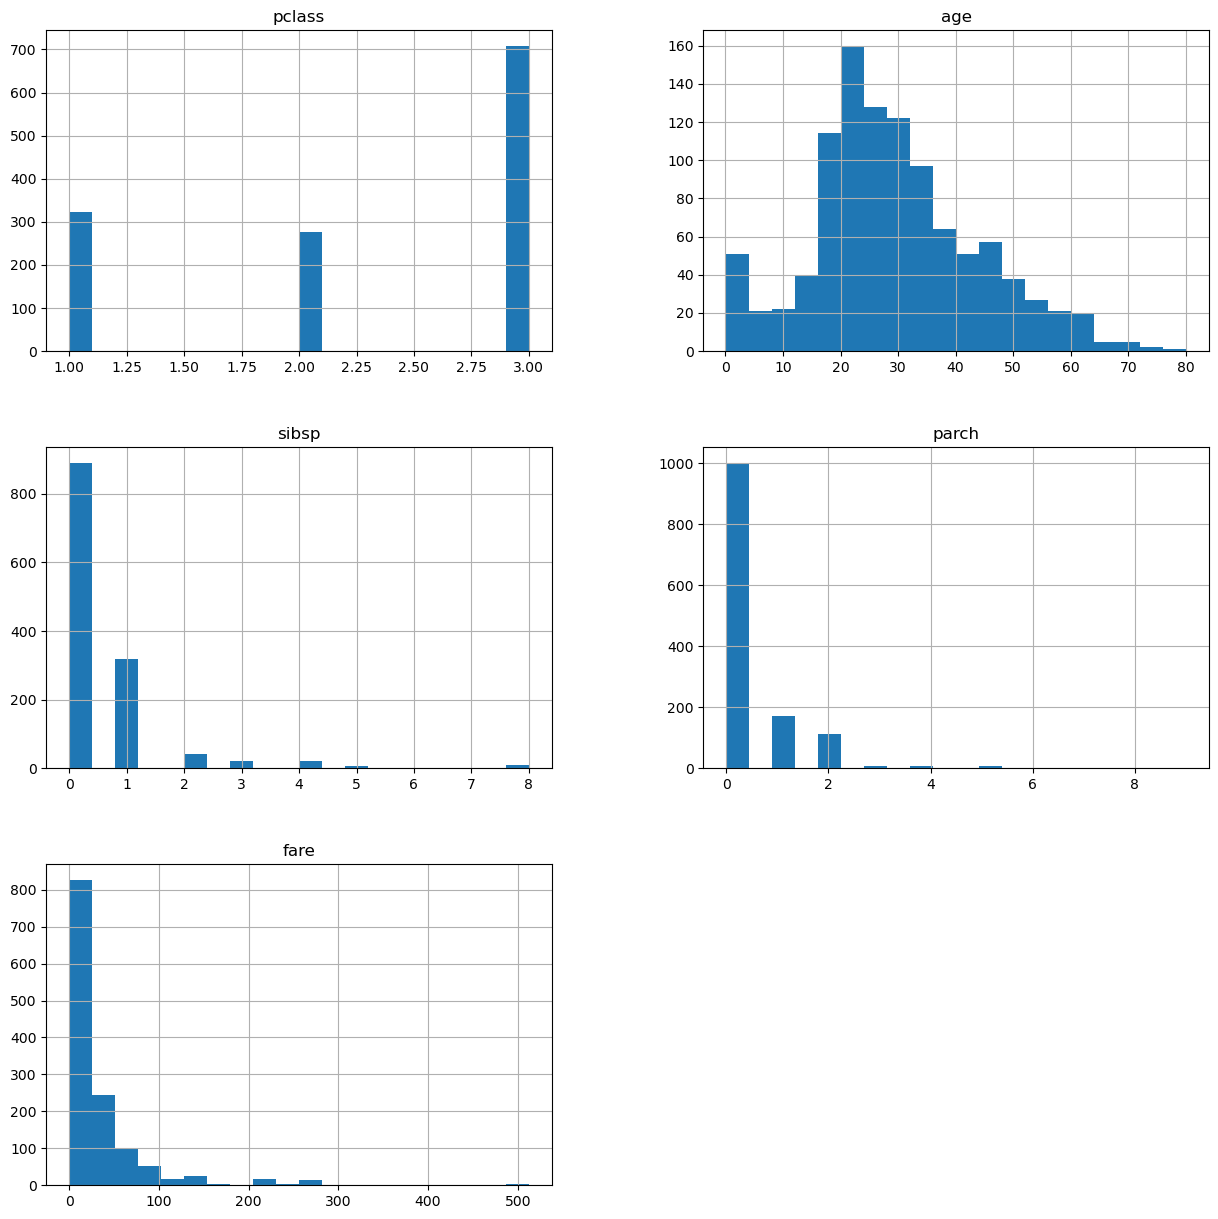

In [20]:
data[vars_num].hist(bins=20, figsize=(15,15));

`parch`, `sibsp` and `fare` are positively skewed but contain zero values

In [21]:
for col in ['parch', 'sibsp', 'fare']:
    print(col, any(data[col] == 0))

parch True
sibsp True
fare True


## Separate data into train and test

Use the code below for reproducibility. Don't change it.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('survived', axis=1),  # predictors
    data['survived'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((1047, 9), (262, 9))

## Feature Engineering

### Extract only the letter (and drop the number) from the variable Cabin

In [25]:
X_train['cabin'] = X_train['cabin'].str.extract('([A-Z]*)')
X_test['cabin'] = X_test['cabin'].str.extract('([A-Z]*)')

### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [28]:
for var in num_na:

    # calculate the mean using the train set
    median_val = X_train[var].median()
    
    print(f"{var:20}{median_val}")

    # add binary missing indicator (in train and test)
    X_train[var + '_na'] = np.where(X_train[var].isnull(), 1, 0)
    X_test[var + '_na'] = np.where(X_test[var].isnull(), 1, 0)

    # replace missing values by the mean
    # (in train and test)
    X_train[var].fillna(median_val, inplace=True)
    X_test[var].fillna(median_val, inplace=True)

age                 28.0
fare                14.4542


### Replace Missing data in categorical variables with the string **Missing**

In [29]:
# replace missing values with new label: "Missing"
X_train[vars_cat] = X_train[vars_cat].fillna('Missing')
X_test[vars_cat] = X_test[vars_cat].fillna('Missing')

### Remove rare labels in categorical variables

- remove labels present in less than 5 % of the passengers

In [30]:
def find_frequent_labels(df, var, rare_perc):
    
    # function finds the labels that are shared by more than
    # a certain % of the houses in the dataset

    df = df.copy()

    tmp = df.groupby(var)[var].count() / len(df)

    return tmp[tmp > rare_perc].index

In [31]:
for var in vars_cat:
    
    # find the frequent categories
    frequent_ls = find_frequent_labels(X_train, var, 0.05)
    
    print(var, frequent_ls)
    print()
    
    # replace rare categories by the string "Rare"
    X_train[var] = np.where(
        X_train[var].isin(frequent_ls), X_train[var], 'Rare'
    )
    
    X_test[var] = np.where(
        X_test[var].isin(frequent_ls), X_test[var], 'Rare'
    )

sex Index(['female', 'male'], dtype='object', name='sex')

cabin Index(['C', 'Missing'], dtype='object', name='cabin')

embarked Index(['C', 'Q', 'S'], dtype='object', name='embarked')

title Index(['Miss', 'Mr', 'Mrs'], dtype='object', name='title')



### Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [37]:
# create new train data combining original data without categorical variables and OHE
new_X_train = pd.get_dummies(X_train, columns=vars_cat, drop_first=True)

# create new test data combining original data without categorical variables and OHE
new_X_test = pd.get_dummies(X_test, columns=vars_cat, drop_first=True)

In [47]:
missing_col = new_X_train.columns[
    ~new_X_train.columns.isin(new_X_test.columns)
]

In [48]:
new_X_test[missing_col] = 0

### Scale the variables

- Use the standard scaler from Scikit-learn

In [55]:
from sklearn.preprocessing import StandardScaler

# create scaler
scaler = StandardScaler()

#  fit  the scaler to the train set
scaler.fit(new_X_train) 

# transform the train and test set
new_X_train = pd.DataFrame(
    scaler.transform(new_X_train),
    columns=new_X_train.columns
)

new_X_test = pd.DataFrame(
    scaler.transform(new_X_test),
    columns=new_X_test.columns
)

In [56]:
# save the scaler
joblib.dump(scaler, 'assignment1_scaler.joblib') 

['assignment1_scaler.joblib']

## Train the Logistic Regression model

- Set the regularization parameter to 0.0005
- Set the seed to 0

In [57]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression(C=0.0005, random_state=0)

lg_model.fit(new_X_train, y_train)

LogisticRegression(C=0.0005, random_state=0)

## Make predictions and evaluate model performance

Determine:
- roc-auc
- accuracy

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [58]:
from sklearn.metrics import roc_auc_score, accuracy_score

# make predictions for train set
class_ = lg_model.predict(new_X_train)
preds = lg_model.predict_proba(new_X_train)[:, 1]

# determine mse, rmse and r2
print('train ROC-AUC:  {}'.format(round(roc_auc_score(y_train, preds), 2)))
print('train accuracy: {}'.format(round(accuracy_score(y_train, class_), 2)))

# make predictions for test set
class_ = lg_model.predict(new_X_test)
preds = lg_model.predict_proba(new_X_test)[:, 1]

# determine mse, rmse and r2
print('test ROC-AUC:  {}'.format(round(roc_auc_score(y_test, preds), 2)))
print('test accuracy: {}'.format(round(accuracy_score(y_test, class_), 2)))

train ROC-AUC:  0.84
train accuracy: 0.71
test ROC-AUC:  0.74
test accuracy: 0.68


That's it! Well done

**Keep this code safe, as we will use this notebook later on, to build production code, in our next assignement!!**

In [35]:
# save the trained model

joblib.dump(lg_model, 'assignement1_model.joblib') 

['assignement1_model.joblib']